# Secondary-Offering-Drift — a quantitative teardown 🔬
### abnormal-return event study · forward drift vs zero · one-sample Welch *t* · same-names left-tail placebo · size-split cut · short-the-issuer costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Dilution_drift%3F: Busted](https://img.shields.io/badge/Dilution_drift%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We mark 34 notable follow-on / secondary offerings and test whether the issuer drifts **down** (dilution + negative signal) — or, here, up.

> ⚠️ **Not investment advice.** Real data: yfinance daily adjusted closes for 27 offering tickers + SPY (as-of 2026-06-30, panel fp `75dc79931e2c`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from secondary_offering_drift import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
if HAVE_REAL:
    PRICES = PRICES.loc[:"2026-06-30"]           # drop the partial current bar (as-of stamp)
print("real event-price cache present:", HAVE_REAL,
      "| offerings in table:", len(data.event_table()))


real event-price cache present: True | offerings in table: 34


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Abnormal drift **+11 / +8 / +8 / +29%** at 1/3/6/12m — the *wrong* sign (claim = down); best *t* **+1.78** (< 2); left-tail placebo *p* 0.531–0.985. |
| **Tradability** | `MIRAGE` | Short-the-issuer P&L **-8%** gross / **-10%** net at 6m (10 bps + 300 bps/yr borrow). Wrong sign before costs. |
| **Dilution drift on the tape?** | `BUSTED` | Positive drift in both size buckets; issuers out-ran SPY for a year. |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this hand-picked roster of recognisable growth-story raisers the dilution drift is absent-to-inverted and never significant.

## 1 · The claim, steelmanned

Let $a_i$ be offering $i$'s **abnormal** forward return (stock − SPY) over horizon $H$.

- **H₁ (the drift).** $\mathbb{E}[a] < 0$ at *t* ≤ −2 (issuers slide beyond the market).
- **H₂ (placebo).** The offering set sits in the *left* tail of a same-names random-date null.
- **H₃ (dose-response).** *Bigger* offerings ⇒ *more* negative drift.
- **H₄ (tradable).** Shorting the issuer, net of borrow, is profitable.

We find **H₁ rejected with the sign reversed** (drift is positive), **H₂ rejected** (the set sits in the *right* tail), **H₃ rejected** (both size halves drift up), and **H₄ rejected** (the short loses before costs).

## 2 · So what? — what rides on each answer

The content is the **why**. The dilution/new-issues effect is documented on *broad, survivorship-free* universes and over *long* horizons, and driven partly by the distressed, deep-discount raises. Two forces kill it here: (a) **selection** — a hand-picked table of recognisable offerings skews to *survivors* and *growth stories* raising at strength; and (b) the discrete-event framing captures a handful of moonshots (Tesla's capital raises, crypto-miner ATMs) whose post-raise rallies swamp the average. The continuous factor on a full basket lives in [519 Net-Share-Issuance](../../519-net-share-issuance/); the mirror event in [368 Buyback-Drift](../../368-buyback-drift/).

## 3 · How we'd know — the protocol

- **Event.** 34 notable follow-on / secondary offerings (ticker, pricing date, $bn).
- **Measure.** Abnormal return $a = (P^{stock}_H/P^{stock}_0 - 1) - (P^{SPY}_H/P^{SPY}_0 - 1)$ at $H \in \{1,3,6,12\}$ months.
- **Entry.** One trading day *after* the offering is public (no look-ahead; past the announcement-day pop).
- **Inference.** One-sample Welch *t* vs 0; a **same-names left-tail placebo** null (20,000 random-date redraws, ask $P[\text{placebo mean} \le \text{offering mean}]$).
- **Robustness.** Median split on deal size.
- **Frictions.** The tradable trade is a **short**: P&L $= -a$, charged a round-trip cost + a pro-rated 300 bps/yr borrow.
- **Positive control.** A deterministic synthetic world with a planted *negative* drift and a null — averaged over 25 seeds (house rule).

## 4 · The teardown

### 4a · The drift vs zero — H₁ & H₂

Abnormal drift at each horizon with the one-sample Welch *t* and the left-tail placebo *p*.

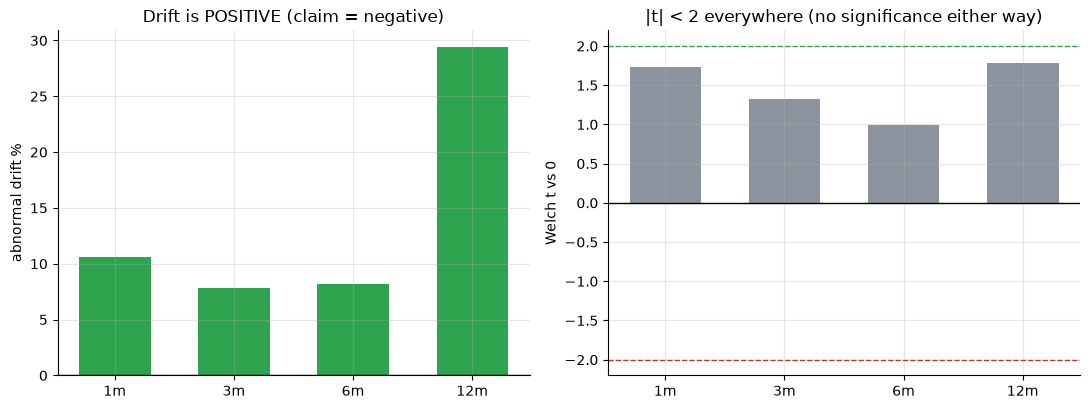

      n   mean%  median%   loss%      t  placebo_p
H                                                 
1m   34  10.598    0.459  50.000  1.729      0.985
3m   34   7.827    3.342  47.059  1.323      0.737
6m   34   8.210    6.194  41.176  0.989      0.532
12m  34  29.437    3.710  47.059  1.778      0.566


In [2]:
hor = [1, 3, 6, 12]
if HAVE_REAL:
    rows = [st.summarize(PRICES, EVENTS, m) for m in hor]
    tab = [(f'{m}m', s['n'], s['ab_mean']*100, s['ab_median']*100, s['loss']*100, s['t'], s['p_placebo'])
           for m, s in zip(hor, rows)]
else:
    tab = [('1m',)+(34, 10.6, 0.46, 50, 1.73, 0.985), ('3m',)+(34, 7.83, 3.34, 47, 1.32, 0.737), ('6m',)+(34, 8.21, 6.19, 41, 0.99, 0.531), ('12m',)+(34, 29.44, 3.71, 47, 1.78, 0.563)]
import pandas as pd
df = pd.DataFrame(tab, columns=['H','n','mean%','median%','loss%','t','placebo_p']).set_index('H')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
cols = [GREEN if m>0 else RED for m in df['mean%']]
ax1.bar(df.index, df['mean%'], color=cols, width=.6); ax1.axhline(0, c='k', lw=1)
ax1.set_ylabel('abnormal drift %'); ax1.set_title('Drift is POSITIVE (claim = negative)')
ax2.bar(df.index, df['t'], color=GREY, width=.6)
ax2.axhline(2, ls='--', c=GREEN, lw=1); ax2.axhline(-2, ls='--', c=RED, lw=1); ax2.axhline(0, c='k', lw=1)
ax2.set_ylabel('Welch t vs 0'); ax2.set_title('|t| < 2 everywhere (no significance either way)')
plt.tight_layout(); plt.show()
print(df.round(3).to_string())

> 💡 In plain words: **H₁ rejected with the sign reversed** and **H₂ rejected.** The drift is *positive* (+11% to +29%), *t* never leaves (−2, +2), and the left-tail placebo *p* is 0.531–0.985 — the offering set sits on the *high* side of the random-date distribution, the opposite of a slide.

### 4b · Dose-response — H₃ (does a bigger offering slide more?)

Median-split on deal size; the dilution story predicts the BIG bucket slides *more*.

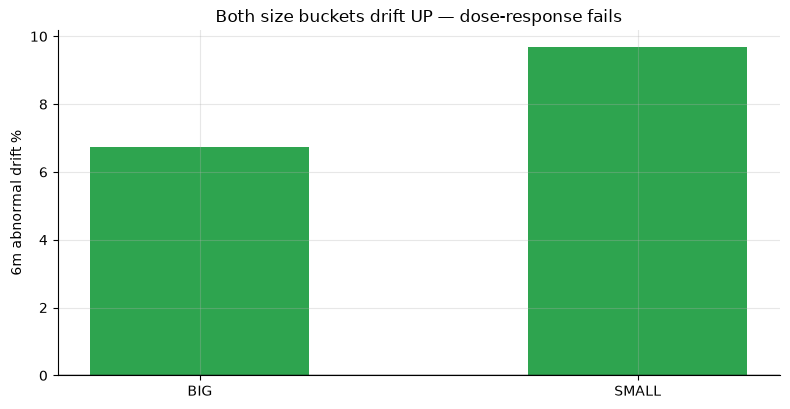

        BIG (>=median): 6m drift +6.7%  (t +0.84)
       SMALL (<median): 6m drift +9.7%  (t +0.65)


In [3]:
if HAVE_REAL:
    rows = st.size_split(PRICES, EVENTS, 6)
    labs = [r['bucket'] for r in rows]; vals = [r['ab_mean']*100 for r in rows]
    ts = [r['t'] for r in rows]
else:
    labs = ['BIG (>=median $1.08bn)', 'SMALL (<median)']
    vals = [6.73, 9.69]; ts = [0.84, 0.65]
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(labs)), vals, color=[GREEN if v>0 else RED for v in vals], width=.5)
ax.set_xticks(range(len(labs))); ax.set_xticklabels([l.split(' ')[0] for l in labs])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('6m abnormal drift %')
ax.set_title('Both size buckets drift UP — dose-response fails')
plt.tight_layout(); plt.show()
for l, v, t in zip(labs, vals, ts): print(f'{l:>22}: 6m drift {v:+.1f}%  (t {t:+.2f})')

> 💡 In plain words: **H₃ rejected.** Both halves drift up (BIG +7%, SMALL +10%), neither significant. 'More shares sold ⇒ bigger slide' is not in this data.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (drift +8% at 6m, wrong sign); H₂ rejected (right-tail placebo *p* 0.531); best *t* +1.78 (< 2).
- **Tradability `MIRAGE`** — short-the-issuer P&L -8% gross → -10% net at 6m (wrong sign before the borrow).
- **Dilution drift on the tape? `BUSTED`** — positive in both size buckets; issuers out-ran SPY for a year.

## 6 · Could you trade it? — the short, costs and the borrow

The tradable expression is a **short** of the issuer, so its P&L is $-a$. Because the drift is positive, the short loses; the punitive borrow only deepens it.

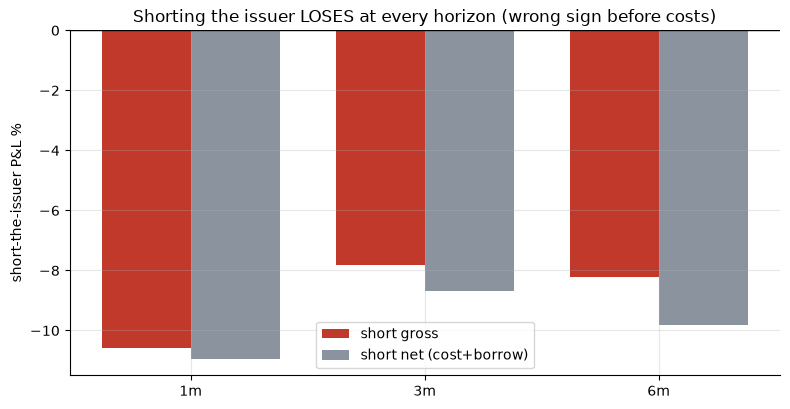

1m: short gross -10.6% -> net -10.9%
3m: short gross -7.8% -> net -8.7%
6m: short gross -8.2% -> net -9.8%


In [4]:
hor = [1, 3, 6]
if HAVE_REAL:
    gross = [st.net_of_costs(PRICES, EVENTS, m)['short_gross']*100 for m in hor]
    net = [st.net_of_costs(PRICES, EVENTS, m)['short_net']*100 for m in hor]
else:
    gross = [-10.6, -7.83, -8.21]
    net = [-10.95, -8.68, -9.81]
x = np.arange(len(hor)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(x-w/2, gross, w, label='short gross', color=RED)
ax.bar(x+w/2, net, w, label='short net (cost+borrow)', color=GREY)
ax.axhline(0, c='k', lw=1); ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hor])
ax.set_ylabel('short-the-issuer P&L %'); ax.legend()
ax.set_title('Shorting the issuer LOSES at every horizon (wrong sign before costs)')
plt.tight_layout(); plt.show()
for m, g, n in zip(hor, gross, net): print(f'{m}m: short gross {g:+.1f}% -> net {n:+.1f}%')

> 💡 In plain words: there is nothing to charge costs against — the short *loses* before frictions, and these are the worst possible names to be short. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector of a *real* downside drift, or does it always print ~0? Plant a genuine negative drift of increasing strength and watch the Welch *t* go negative — averaged over 25 seeds so no single lucky seed can fake it.

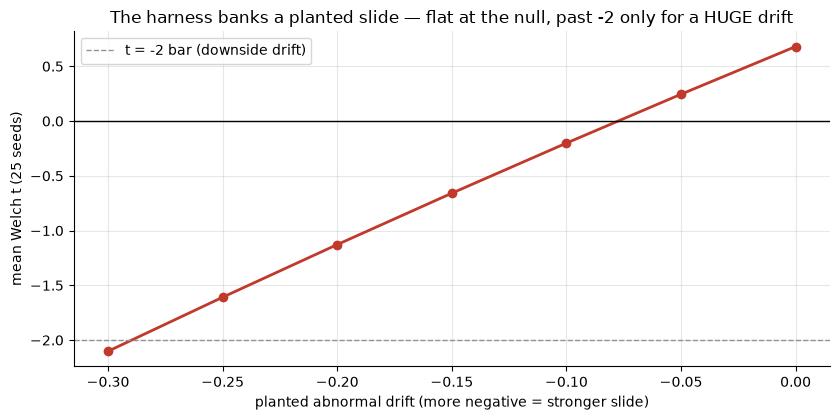

planted +0.00 -> mean t +0.68
planted -0.05 -> mean t +0.25
planted -0.10 -> mean t -0.20
planted -0.15 -> mean t -0.66
planted -0.20 -> mean t -1.13
planted -0.25 -> mean t -1.61
planted -0.30 -> mean t -2.10


In [5]:
edges = [0.0, -0.05, -0.10, -0.15, -0.20, -0.25, -0.30]
rows = [st.synthetic_control(data.synthetic_events, edges=(e,), months=6, n_seeds=25)[0] for e in edges]
ts = [r['mean_t'] for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(edges, ts, 'o-', c=RED, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (downside drift)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted abnormal drift (more negative = stronger slide)')
ax.set_ylabel('mean Welch t (25 seeds)')
ax.set_title('The harness banks a planted slide — flat at the null, past -2 only for a HUGE drift')
ax.legend(); plt.tight_layout(); plt.show()
for e, t in zip(edges, ts): print(f'planted {e:+.2f} -> mean t {t:+.2f}')

The seed-averaged *t* is ≈ +0.7 at the null and only falls past −2 when the planted slide is a huge −30% over six months — so the engine is a faithful detector, **and** ~34 single-name events are too few to catch any slide of plausible size (at the null, some individual seeds still cross |t| = 2 by luck, which is exactly why we average). The real-tape result is therefore a statement about **this survivor/visibility-selected basket**: the dilution drift is absent-to-inverted here. For the factor and the mirror event, see [519 Net-Share-Issuance](../../519-net-share-issuance/) and [368 Buyback-Drift](../../368-buyback-drift/).